# $\mathrm{Ca}_{\mathrm{V}}1.2$ Timothy mutations: IS6 coupling analysis

G402S and G406R are gain-of-function mutations because they suppress channel inactivation and sustain inward calcium current. Here we test whether the predicted ensembles suggest distinct structural mechanisms at the domain-I S6 interface. Static structural similarity is kept separate from functional state assignment: an inactive-like distance does not prove that a model can enter or maintain physiological inactivation.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

repo_root = Path.cwd() if (Path.cwd()/"shared").is_dir() else Path.cwd().parent
sys.path.insert(0, str(repo_root))
from shared.plotting import CAV12_PALETTE, apply_kv21_style
from shared.cav12_coupling_analysis import (
    plot_timothy_contact_occupancy,
    plot_gate_and_local_coupling,
    plot_experimental_interface_landscapes,
)
apply_kv21_style()
data_dir = repo_root/'cav12'/'dataDistances'
figure_dir = repo_root.parent/'vgci_mutants_writing'/'figures'/'cav12'
figure_dir.mkdir(parents=True, exist_ok=True)

In [2]:
specifications = {
 'WT | vanilla': ('26-02-10_Cav12_wt_vanillaAF2_distances_all_ok_rmsd_3A.csv','WT','vanilla',CAV12_PALETTE['WT_VAN']),
 'G402S | vanilla': ('26-02-10_Cav12_g402s_vanillaAF2_distances_all_ok_rmsd_3A.csv','G402S','vanilla',CAV12_PALETTE['G402S_VAN']),
 'G406R | vanilla': ('26-07-25_Cav1.2_g406r_vanillaAF2_distances_all_ok_rmsd_3A.csv','G406R','vanilla',CAV12_PALETTE['G406R_VAN']),
 'WT | masked': ('26-02-10_Cav12_wt_maskedAF2_distances_all_ok_rmsd_3A.csv','WT','masked',CAV12_PALETTE['WT_HM']),
 'G402S | masked': ('26-02-10_Cav12_g402s_maskedAF2_distances_all_ok_rmsd_3A.csv','G402S','masked',CAV12_PALETTE['G402S_HM']),
 'G406R | masked': ('26-07-25_Cav1.2_g406r_maskedAF2_distances_all_ok_rmsd_3A.csv','G406R','masked',CAV12_PALETTE['G406R_HM']),
}
datasets = {label:(pd.read_csv(data_dir/filename),condition,protocol) for label,(filename,condition,protocol,color) in specifications.items()}
palette = {label:color for label,(_,_,_,color) in specifications.items()}
{label:len(frame) for label,(frame,_,_) in datasets.items()}

{'WT | vanilla': 5000,
 'G402S | vanilla': 5000,
 'G406R | vanilla': 5000,
 'WT | masked': 4996,
 'G402S | masked': 4995,
 'G406R | masked': 4997}

## Distinct local repacking

G402S is evaluated as an exchange between the WT G402–M1524 proximity and the introduced S402–I1523 contact. G406R is evaluated against the acidic D1528 and D1533 partners. R406–T1531 is deliberately excluded from the mechanistic panel because its sub-2 Å distances indicate atomic overlap in many models.

,Dataset,Condition,Protocol,Contact,Contact fraction
0,WT | vanilla,WT,vanilla,G402/S402–I1523,0.000
1,WT | vanilla,WT,vanilla,G402/S402–M1524,0.311
2,WT | vanilla,WT,vanilla,G406/R406–D1528,0.099
3,WT | vanilla,WT,vanilla,G406/R406–D1533,0.000
4,G402S | vanilla,G402S,vanilla,G402/S402–I1523,0.192
5,G402S | vanilla,G402S,vanilla,G402/S402–M1524,0.000
6,G402S | vanilla,G402S,vanilla,G406/R406–D1528,0.261
7,G402S | vanilla,G402S,vanilla,G406/R406–D1533,0.000
8,G406R | vanilla,G406R,vanilla,G402/S402–I1523,0.000
9,G406R | vanilla,G406R,vanilla,G402/S402–M1524,0.248


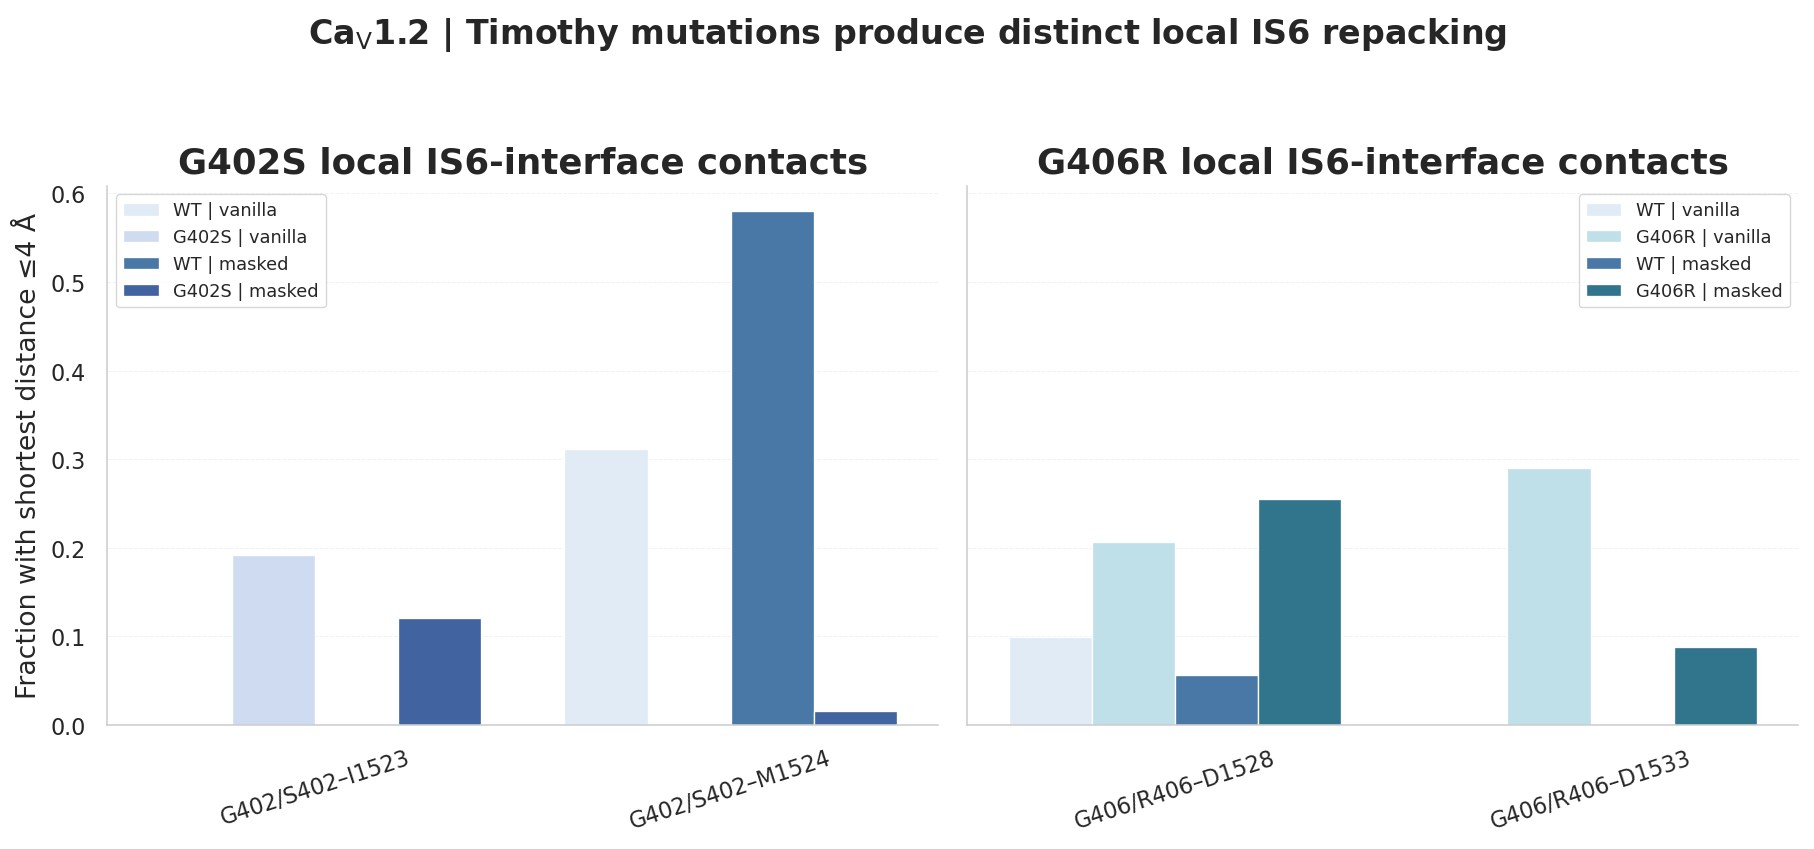

In [3]:
contact_table, fig = plot_timothy_contact_occupancy(datasets, palette)
display(contact_table.round(3))
fig.savefig(figure_dir/'Cav12_Timothy_local_contact_occupancy.png',dpi=300,bbox_inches='tight')
fig.savefig(figure_dir/'Cav12_Timothy_local_contact_occupancy.pdf',bbox_inches='tight')
plt.show()

## Local rearrangement versus global gate opening

The gate violin tests whether either mutation simply stabilizes a wider pore. The scatter panels instead ask whether local IS6-interface movement is coordinated with gate sampling. A correlation describes coordinated geometry, not transition kinetics or causal inactivation.

/Users/ahernandezgonzalez/Repositories/vgci_mutants/shared/cav12_coupling_analysis.py:126: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


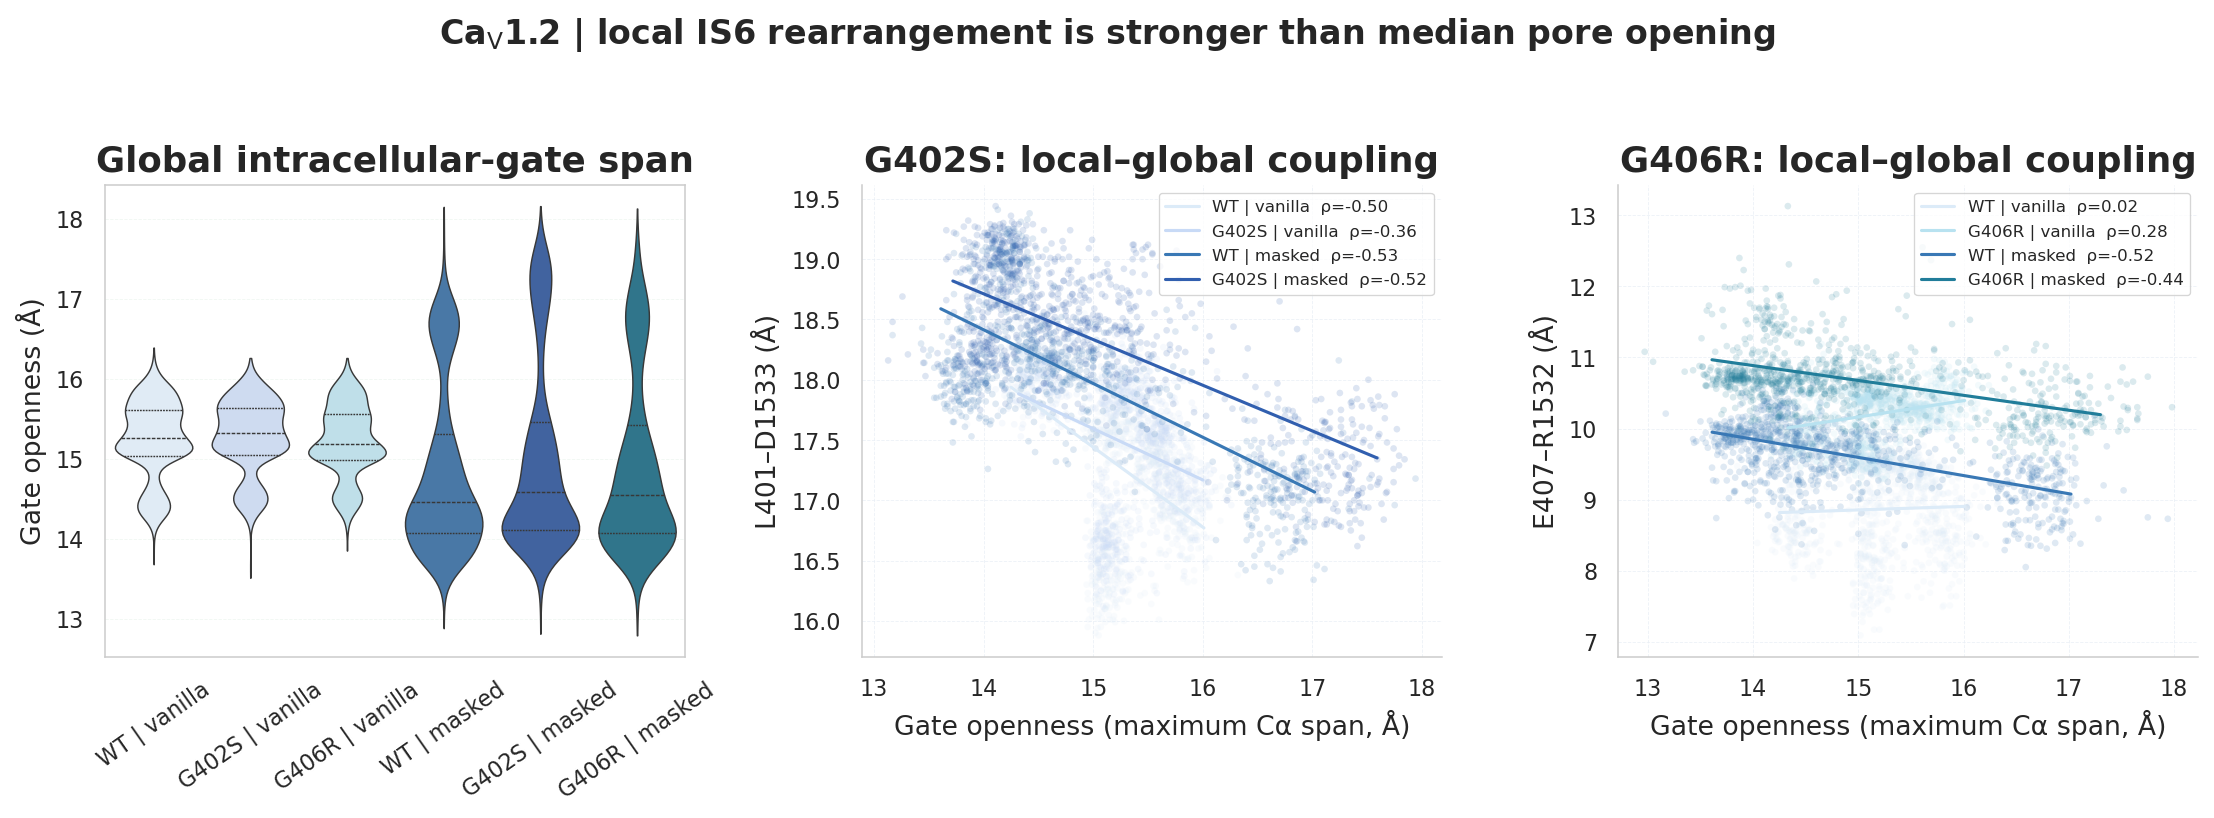

In [4]:
gate_table, fig = plot_gate_and_local_coupling(datasets, palette)
fig.savefig(figure_dir/'Cav12_Timothy_gate_local_coupling.png',dpi=300,bbox_inches='tight')
fig.savefig(figure_dir/'Cav12_Timothy_gate_local_coupling.pdf',bbox_inches='tight')
plt.show()

## Experimental S6-interface reference landscapes

These panels use raw Cα coordinates that are shared by all ensembles and directly measurable in 8HLP, 8WE6, and 8FD7. The points show geometric proximity only. 8FD7 is gabapentin-bound and must not be treated as a pure physiological state endpoint; 8HLP and 8WE6 are apo structural references rather than a complete kinetic state series.

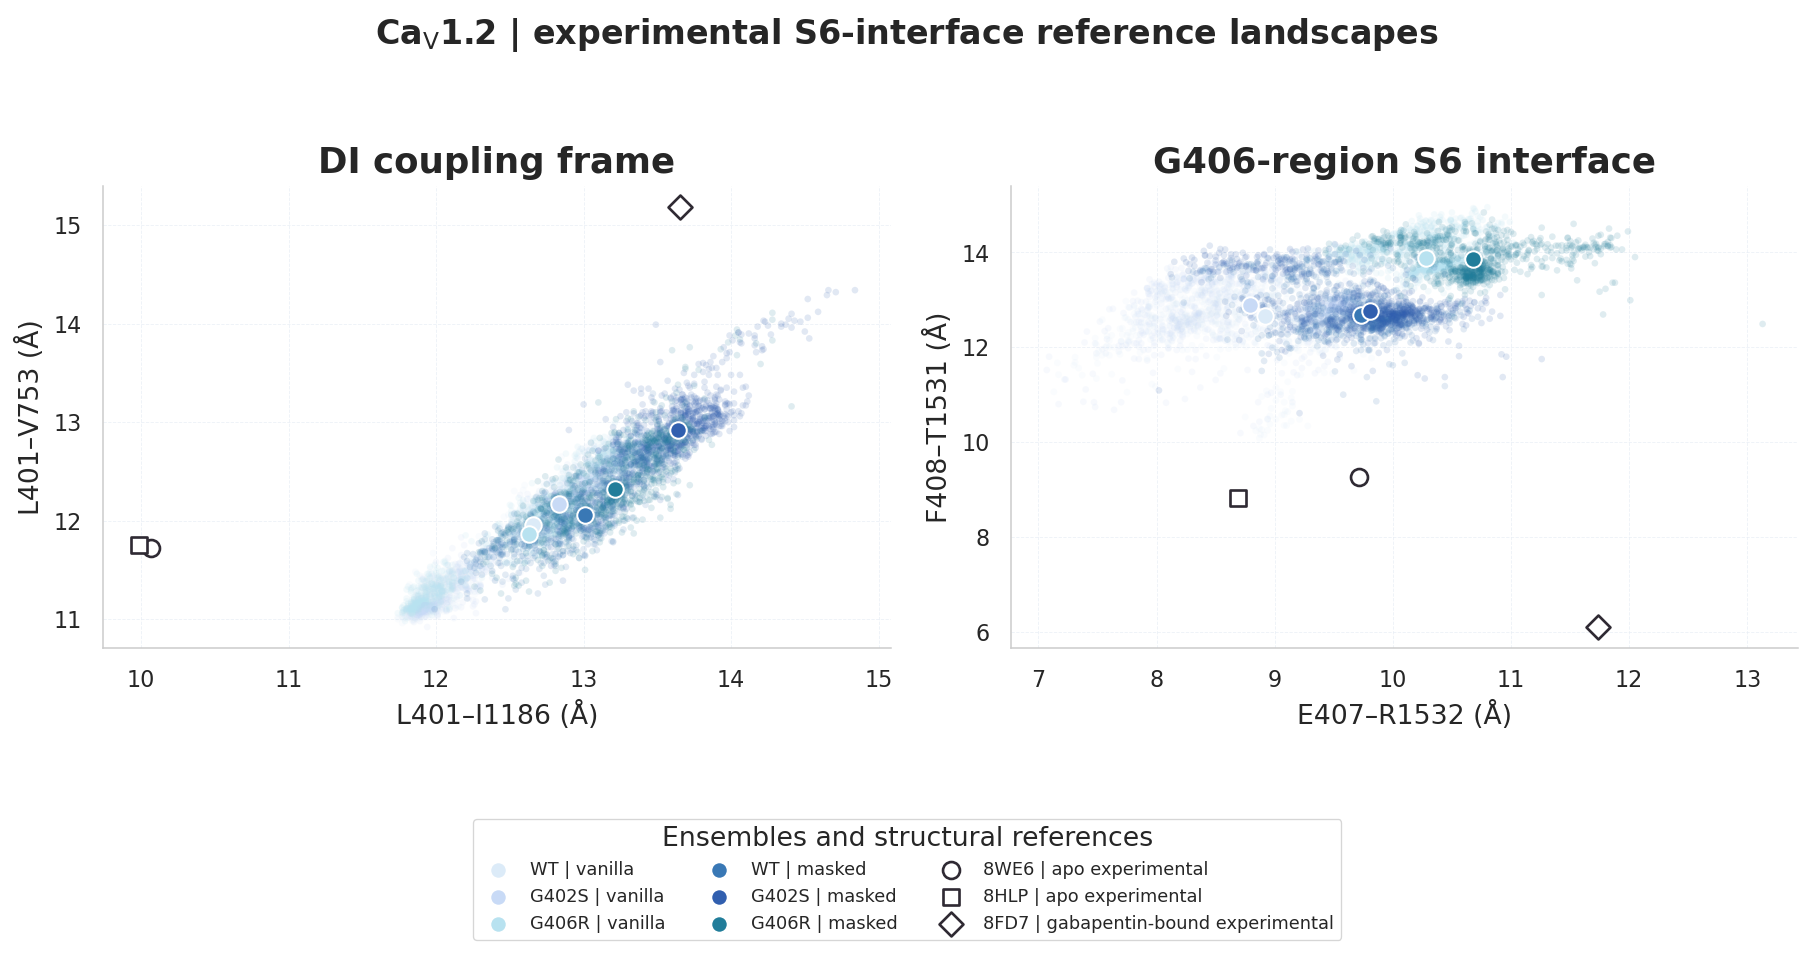

In [5]:
EXPERIMENTAL = {
 '8WE6 | apo': {
  'CA_LEU401_CA-ILE1186_CA':10.070, 'CA_LEU401_CA-VAL753_CA':11.718,
  'CA_GLU407_CA-ARG1532_CA':9.716, 'CA_PHE408_CA-THR1531_CA':9.273,
 },
 '8HLP | apo': {
  'CA_LEU401_CA-ILE1186_CA':9.986, 'CA_LEU401_CA-VAL753_CA':11.751,
  'CA_GLU407_CA-ARG1532_CA':8.687, 'CA_PHE408_CA-THR1531_CA':8.828,
 },
 '8FD7 | gabapentin-bound': {
  'CA_LEU401_CA-ILE1186_CA':13.653, 'CA_LEU401_CA-VAL753_CA':15.182,
  'CA_GLU407_CA-ARG1532_CA':11.739, 'CA_PHE408_CA-THR1531_CA':6.103,
 },
}
fig = plot_experimental_interface_landscapes(datasets,palette,EXPERIMENTAL)
fig.savefig(figure_dir/'Cav12_Timothy_experimental_interface_landscapes.png',dpi=300,bbox_inches='tight')
fig.savefig(figure_dir/'Cav12_Timothy_experimental_interface_landscapes.pdf',bbox_inches='tight')
plt.show()